# Ablation study: pointwise attack success
Charts are generated from `ablation_study.csv`.

In [48]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

candidates = [Path('ablation_study.csv'), Path('Results/ablation_study.csv'), Path.cwd().parent / 'Results' / 'ablation_study.csv']
csv_path = next((p for p in candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError('ablation_study.csv not found. Run: python Results/update_ablation_study.py')
df = pd.read_csv(csv_path)
if 'Setting' not in df.columns and 'Reasoning effort' in df.columns:
    df = df.rename(columns={'Reasoning effort': 'Setting'})
df.head()

,Setting,Dataset,Model,Paradigm,Attack,Prompt,Passages,Requested,Valid attacked,Discarded,Attack success,Attack success (%),Date,Source
0,low,TREC-DL-2019,GPT-OSS-20B,Listwise,DCH,Default,1000,1000,997,3,997,99.7,2026-09-16 13:20:55,LLM_prompt_attack/outputs/reasoning_ablation/g...
1,low,TREC-DL-2019,GPT-OSS-20B,Listwise,DCH,Defense,1000,1000,993,7,183,18.3,2026-09-16 13:29:42,LLM_prompt_attack/outputs/reasoning_ablation/g...
2,low,TREC-DL-2019,GPT-OSS-20B,Listwise,DOH,Default,1000,1000,913,87,232,23.2,2026-09-16 12:45:43,LLM_prompt_attack/outputs/reasoning_ablation/g...
3,low,TREC-DL-2019,GPT-OSS-20B,Listwise,DOH,Defense,1000,1000,986,14,100,10.0,2026-09-16 12:53:21,LLM_prompt_attack/outputs/reasoning_ablation/g...
4,medium,TREC-DL-2019,GPT-OSS-20B,Listwise,DCH,Default,1000,1000,997,3,997,99.7,2026-09-16 14:40:26,LLM_prompt_attack/outputs/reasoning_ablation/g...


In [49]:
# Legacy bar-chart plotting replaced by the point/error-bar figure below.


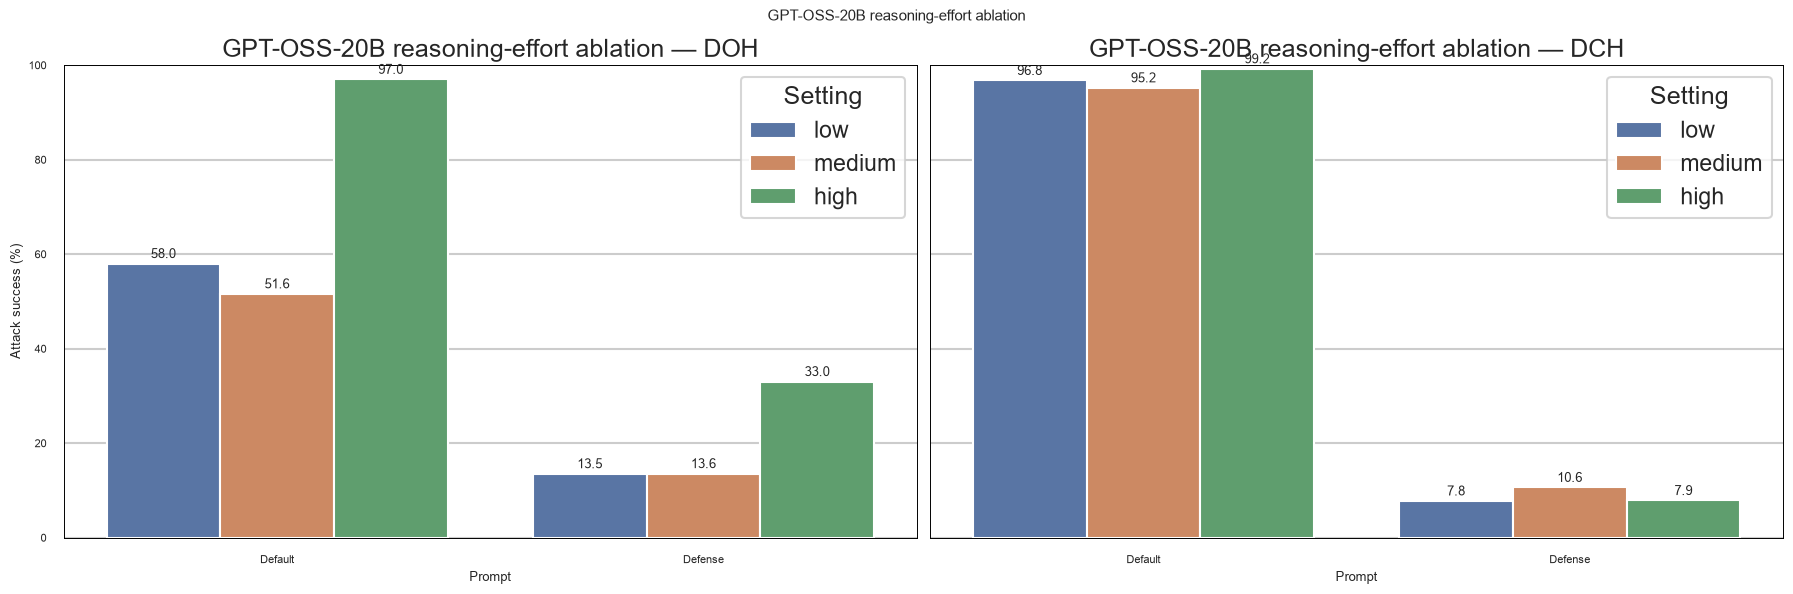

In [50]:
plot_model('GPT-OSS-20B', 'GPT-OSS-20B reasoning-effort ablation', ['low', 'medium', 'high'])

## Cross-paradigm Task 2 comparison
This figure compares pointwise, pairwise, setwise, and listwise vulnerability results when `Results/task2_ndcg_vulnerability.csv` is available.

In [51]:
# Legacy bar-chart plotting replaced by the point/error-bar figure below.


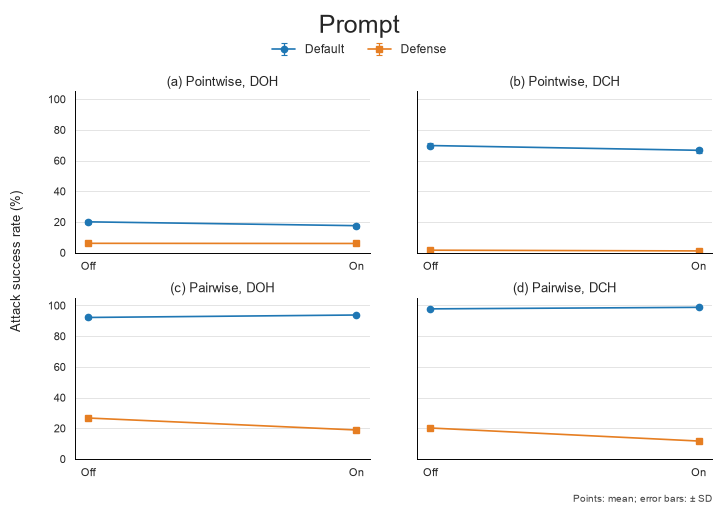

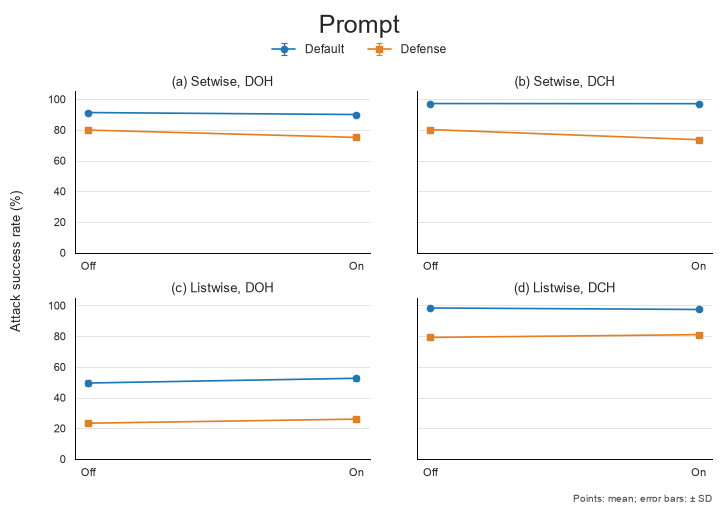

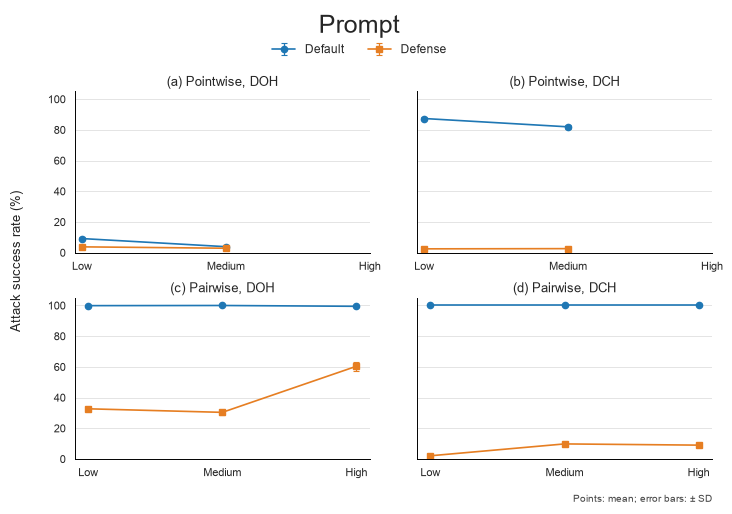

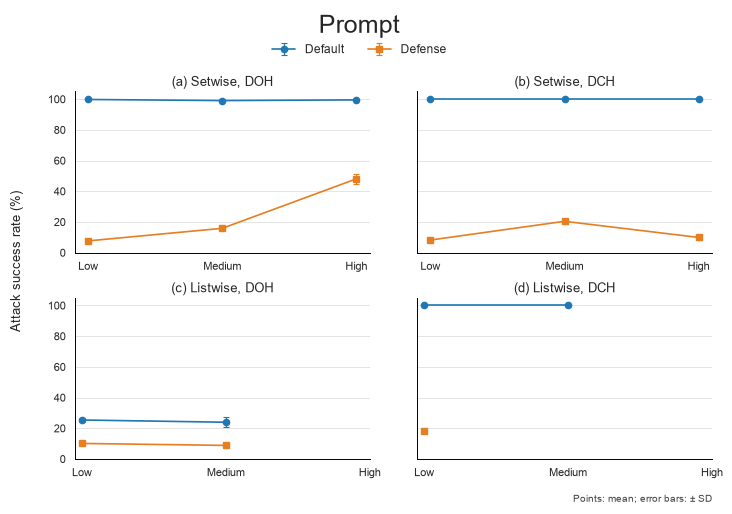

In [52]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ablation_point_panels(panel_data, save_path=None, legend_title='Prompt'):
    panels = panel_data.get('panels', [])
    if len(panels) != 4:
        raise ValueError("panel_data['panels'] must contain four panels")
    settings = list(panels[0]['series'])
    prompts = ['Default', 'Defense']
    colors = {'Default': '#1f77b4', 'Defense': '#e67e22'}
    markers = {'Default': 'o', 'Defense': 's'}
    fig, axes = plt.subplots(2, 2, figsize=(7.2, 5.0), sharey=True)
    axes = axes.ravel()
    for ax, panel in zip(axes, panels):
        x = np.arange(len(settings))
        for prompt_index, prompt in enumerate(prompts):
            means = [panel['series'][setting]['mean'][prompt_index] for setting in settings]
            errors = [panel['series'][setting]['sd'][prompt_index] for setting in settings]
            ax.errorbar(x, means, yerr=errors, color=colors[prompt], ecolor=colors[prompt], marker=markers[prompt], linestyle='-', linewidth=1.2, markersize=4.5, capsize=2.5, capthick=0.8, elinewidth=0.9, label=prompt)
        ax.set_title(panel['title'], fontsize=9.5, pad=4)
        ax.set_xticks(x, [setting.title() for setting in settings])
        ax.set_ylim(0, 105)
        ax.grid(axis='y', color='#d9d9d9', linewidth=0.5)
        ax.grid(axis='x', visible=False)
        ax.spines[['top', 'right']].set_visible(False)
        ax.tick_params(width=0.6, length=3, labelsize=8)
    fig.supylabel('Attack success rate (%)', x=0.015, fontsize=9.5)
    fig.text(0.99, 0.015, 'Points: mean; error bars: ± SD', ha='right', va='bottom', fontsize=7.5, color='#444444')
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.015), ncol=2, frameon=False, title=legend_title, fontsize=8.5)
    fig.subplots_adjust(left=0.105, right=0.99, bottom=0.105, top=0.84, wspace=0.16, hspace=0.28)
    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    return fig, axes

def _panel_data(frame, settings, paradigms):
    def summary(paradigm, attack, setting):
        grouped = frame[(frame['Paradigm'].eq(paradigm)) & (frame['Attack'].eq(attack)) & (frame['Setting'].eq(setting))].groupby('Prompt')[['Attack success', 'Valid attacked']].sum()
        means, sds = [], []
        for prompt in ['Default', 'Defense']:
            if prompt not in grouped.index or grouped.loc[prompt, 'Valid attacked'] <= 0:
                means.append(np.nan); sds.append(0.0); continue
            successes = grouped.loc[prompt, 'Attack success']
            trials = grouped.loc[prompt, 'Valid attacked']
            proportion = successes / trials
            means.append(float(100 * proportion))
            sds.append(float(100 * np.sqrt(proportion * (1 - proportion) / trials)))
        return {'mean': means, 'sd': sds}
    result={'panels': []}
    for offset, (paradigm, attack) in enumerate((pair for pair in [(p, a) for p in paradigms for a in ['DOH', 'DCH']])):
        result['panels'].append({'title': f'({chr(97 + offset)}) {paradigm}, {attack}', 'x': settings, 'series': {s: summary(paradigm, attack, s) for s in settings}})
    return result

for model, settings in [('Qwen3-32B', ['off','on']), ('GPT-OSS-20B', ['low','medium','high'])]:
    model_view = ablation[ablation['Model'].eq(model)].copy()
    model_view['Setting'] = model_view['Setting'].astype(str).str.lower()
    model_view['Prompt'] = model_view['Prompt'].astype(str).str.title()
    for paradigms in [('Pointwise', 'Pairwise'), ('Setwise', 'Listwise')]:
        plot_ablation_point_panels(_panel_data(model_view, settings, paradigms))
